In [93]:
import numpy as np
from scipy.integrate import odeint
# import sympy as smp

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
from mpl_toolkits.mplot3d import axes3d

# Problem 1

Consider the Ricker model
$$x\to b x e^{-cx}$$
where $x\ge 0$, and $b,c>0$. Also Consider the Beverton-Holt model
$$x\to \frac{rx}{1+x/m}$$
where $x\ge 0$, and $r,m>0$.

Do a fixed point stability analysis for each model (all non-negative fixed points), and based upon the resulting eigenvalue expressions, discuss which generic codimension-1 bifurcations of  fixed points each model might exhibit ("might" because center manifold reduction is not required). Find parameter values where those bifurcations occur, where possible. Optionally, consider checking your results with numerical examples. 

-----

## Ricker Model

Ricker fixed point
$$\begin{align}x=&bxe^{-cx}\\
0=&x-bxe^{-cx}\\
0=&x(1-be^{-cx})\end{align}$$
So the fixed points are given by 
$$\boxed{x=\begin{cases}0\\ \left[ln(b^{1/c})\right]\end{cases}}$$


### b, bifurcation

Creating a parameter dependent system with $b$
$$\begin{align*}J^b = \begin{bmatrix}b\cdot e^{-cx} - bxce^{-cx}&xe^{-cx}\\
0&0\end{bmatrix}\end{align*}$$
Then for the first fixed point $x=0$
$$\begin{align*}J^b_0 = \begin{bmatrix}b &0\\
0&0\end{bmatrix}\end{align*}$$
Corresponding to eigenvalues $\lambda = \{b,0\}$. Given a map is stable for the absolute value of eigenvalues less than 1, then stability for this fixed point might occure for $b<1$ (since $b$ is strictly positive). Now the second fixed point
$$\begin{align*}J^b_0 = \begin{bmatrix}1-ln(b) & \frac{ln(b)}{bc}\\
0&0\end{bmatrix}\end{align*}$$
Corresponding to eigenvalues $\lambda = \{0,1-ln(b)\}$. For this fixed point stability might occure for $|1-ln(b)|<1$ which is satisfied by $1<b<e^2$.

### c, bifurcation

Creating a parameter dependent system with $c$
$$\begin{align*}J^c = \begin{bmatrix}b\cdot e^{-cx} - bxce^{-cx}&-bx^2e^{-cx}\\
0&0\end{bmatrix}\end{align*}$$
Then for the first fixed point $x=0$
$$\begin{align*}J^c_0 = \begin{bmatrix}b &0\\
0&0\end{bmatrix}\end{align*}$$
Corresponding to eigenvalues $\lambda = \{b,0\}$. Which is the same as the previous system. Now the second fixed point
$$\begin{align*}J^c_0 = \begin{bmatrix}1-ln(b) & -\frac{ln(b^2)}{c^2}\\
0&0\end{bmatrix}\end{align*}$$
Corresponding to eigenvalues $\lambda = \{0,1-ln(b)\}$. Again the same as the previouse system.

### Symbolic algebra solver

In [ ]:
# x,b,c,r,m = smp.symbols('x b c r m')

# ricker = b*x*smp.exp(-c*x)

# ricker_zero = x*(1-b*smp.exp(-c*x))
# ricker_zero

In [ ]:
# smp.solve(ricker_zero,x)

In [ ]:
# Jb = smp.Matrix([[smp.diff(ricker,x),smp.diff(ricker,b)],
#                  [0,0]])
# Jb

In [ ]:
# Jb0 = Jb.subs(x,0)
# Jb0

In [ ]:
# Jb0.eigenvals()

In [ ]:
# Jb02 = Jb.subs(x,smp.log(b)/c)
# Jb02

In [ ]:
# Jb02.eigenvals()

In [ ]:
# Jc = smp.Matrix([[smp.diff(ricker,x),smp.diff(ricker,c)],
#                  [0,0]])
# Jc

In [ ]:
# Jc0 = Jc.subs(x,0)
# Jc0

In [ ]:
# Jc02 = Jc.subs(x,smp.log(b)/c)
# Jc02

In [ ]:
# Jc02.eigenvals()

## Beverton-Holt Model




Beverton-Holt
$$\begin{align}x=&\frac{rx}{1+x/m}\\
0=&x(1+x/m)-rx\\
0=&x^2 + xm(1-r)\\
0=&x(x+\beta)\end{align}$$
Whith $\beta\equiv m(r-1)$, the fixed points are given by 
$$\boxed{x=\begin{cases}0\\ -\beta\end{cases}}$$

### m, parameter system

The Jacobian of the parameter system dependent on $m$
$$\begin{align*}J^m = \begin{bmatrix}\frac{r}{1+x/m}-\frac{rx}{m(1+x/m)^2} & \frac{rx^2}{m^2(1+x/m)^2}\\
0&0\end{bmatrix}\end{align*}$$
Plugging in the firs fixed point $x=0$
$$\begin{align*}J^m_0 = \begin{bmatrix}r & 0\\
0&0\end{bmatrix}\end{align*}$$
Corresponding to eigenvalues $\lambda = \{r,0\}$. Given a map is stable for the absolute value of eigenvalues less than 1, then stability for this fixed point might occure for $r<1$ (since $r$ is strictly positive). Now the second fixed point
$$\begin{align*}J^m_0 = \begin{bmatrix}1-\frac{r-1}{r} & \frac{(r-1)^2}{r}\\
0&0\end{bmatrix}\end{align*}$$
Corresponding to eigenvalues $\lambda=\{0,1/r\}$. For this fixed point stability might occure for $1/r<1$ which is satisfied by $1<r$. Similar to the Ricker Model, changing the parameter from $m$ to $r$ doesn't chang the linearized eigenvaluse about the fixed point. 

### Symbolic algebra solver

In [ ]:
# x,b,c,r,m = smp.symbols('x b c r m')
# holt = (r*x)/(1+x/m)
# holt

In [ ]:
# smp.solve(holt-x,x)

In [ ]:
# Jm = smp.Matrix([[smp.diff(holt,x),smp.diff(holt,m)],
#                  [0,0]])
# Jm

In [ ]:
# Jm0 = Jm.subs(x,0)
# Jm0

In [ ]:
# Jm0.eigenvals()

In [ ]:
# Jm02 = Jm.subs(x,m*(r-1))
# Jm02

In [ ]:
# Jm02.eigenvals()

In [ ]:
# Jr = smp.Matrix([[smp.diff(holt,x),smp.diff(holt,r)],
#                  [0,0]])
# Jr

In [ ]:
# Jr02 = Jr.subs(x,m*(r-1))
# Jr02

In [ ]:
# Jr02.eigenvals()

# Problem 2

Consider the Henon map
$$\begin{pmatrix}x\\ y\end{pmatrix}\to
\begin{pmatrix}y \\ a-bx-y^2\end{pmatrix}$$
This system exhibits fold, flip, and Neimark-Sacker bifurcations. Here, you will find equations for the fold and flip bifurcations in $a\times b$ parameter space.

To do this first observe that we can state the fixed point condition as $y^2+(b+1)y-a=0$, and the fold and flip conditions can be stated in terms of Jacobian determinants, for example, for the fold bifurcation with egenvalue 1, a necessary condition is $det(J-I)=0$

1. Show that the fold bifurcation curve must satisfy the two conditions $y^2 +(b+1)y-a=0$ and $b+1+2y=0$ by showing that for some fixed point, $det(J-I)=0$ yields the second condition.
2. Next, to find the bifurcation curve, solve $y^2+(b+1)y-a=0$ and $b+1+2y=0$ by eliminating $y$ to show that the fold bifurcation curve is given by $a=-\frac{(1+b)^2}{4}$
3. Follow the same process but for the flip bifurcation (which has one eigenvalue with value $-1$)

-----

## 1

The Jacobian for the Henon map is 
$$\begin{align}J = 
\begin{bmatrix}0&1\\
-b&-2y\end{bmatrix}\end{align}$$
Then $det(J-I)=0$
$$\begin{align}0=&\begin{vmatrix}-1&1\\
-b&-1-2y\end{vmatrix}\\
0=&(-1)(-1-2y)-(1)(-b)\\
0=&1+2y+b\\
y=&-\frac{b+1}{2}\end{align}$$
Plugging this value of $y$ into the Jacobian
$$\begin{align}J = 
\begin{bmatrix}0&1\\
-b& b+1\end{bmatrix}\end{align}$$
Corresponds to eigenvalues: $\lambda=\{1,b\}$

## 2

From condition 2
$$y = -\frac{1+b}{2}$$
plugging into condition 1
$$\begin{align}0=&\left(-\frac{1+b}{2}\right)^2 + (b+1)\left(-\frac{1+b}{2}\right)-a\\
a=&\frac{(1+b)^2}{4} - \frac{(1+b)^2}{2}\\
a=& - \frac{(1+b)^2}{4}\end{align}$$

## 3

The Jacobian for the Henon map is 
$$\begin{align}J = 
\begin{bmatrix}0&1\\
-b&-2y\end{bmatrix}\end{align}$$
Then $det(J+I)=0$
$$\begin{align}0=&\begin{vmatrix}1&1\\
-b&1-2y\end{vmatrix}\\
0=&(1)(1-2y)-(1)(-b)\\
0=&1-2y+b\\
y=&\frac{b+1}{2}\end{align}$$
Plugging this value of $y$ into the Jacobian
$$\begin{align}J = 
\begin{bmatrix}0&1\\
-b& -(b+1)\end{bmatrix}\end{align}$$
Corresponds to eigenvalues: $\lambda=\{-1,-b\}$. Plugging this value of $y$ into condition 1
$$\begin{align}0=&\left(\frac{1+b}{2}\right)^2 + (b+1)\left(\frac{1+b}{2}\right)-a\\
a=&\frac{(1+b)^2}{4} + \frac{(1+b)^2}{2}\\
a=&\frac{3(1+b)^2}{4}\end{align}$$

## Symbolic Algebra

In [98]:
# x,y,a,b = smp.symbols('x y a b')

# henon = smp.Matrix([[y],[a-b*x-y**2]])
# henon

In [99]:
# J = smp.Matrix([[smp.diff(henon[0],x),smp.diff(henon[0],y)],
#                [smp.diff(henon[1],x),smp.diff(henon[1],y)]])
# J

In [100]:
# det_JI = smp.Matrix.det(J + smp.Matrix.eye(2))
# det_JI

In [101]:
# y_sub = smp.solve(det_JI,y)[0]
# y_sub

In [102]:
# J_sub = J.subs(y,y_sub)
# J_sub

In [ ]:
# J_sub.eigenvals()

(2,)

# Problem 3

Rossler Equations exhibit period doubling bifurcations of limit cycles. The system can be written as 
$$\begin{align}\dot x=&-y-z\\
\dot y =& x+ay\\
\dot z =&b+z(x-c)\end{align}$$

First, read the full Rössler chaotic attractor entry at http://www.scholarpedia.org/article/Rossler_attractor.

Second, numerically explore this system by plotting the following numerical solutions (illustrate these attractors by plotting the tail of trajectories which converge to them) using the parameter values associated with Figure 6 as a guide: 

1. a typical limit cycle, 
2. the limit cycle that results from the first period doubling bifurcation of the limit cycle in part a, 
3. the limit cycle that results from the 2nd period doubling bifurcation, 
4. an example of “spiral-type chaos”, and 
5. an example of “screw-type chaos”.

-----

In [85]:
def Rossler(X,t,a,b,c):
    x,y,z = X
    # a,b,c = X[3:]
    
    dx = -y - z
    dy = x + a*y
    dz = b + z*(x-c)
    return [dx,dy,dz]

In [213]:
from scipy.signal import find_peaks

A = np.linspace(0.2, 0.55, 3000)
b, c = 2, 4

# Phase 1: long transient to discard (let attractor settle)
t_trans   = np.linspace(0, 500, 8000)
# Phase 2: collect steady-state data
t_collect = np.linspace(0, 300, 8000)

x0 = [0.0, -3.0, 3.0]   # single starting point; continuation carries it forward

A_plot = []
Y_plot = []

for a in A:
    # Discard transient — warm start for next iteration (continuation)
    soln_trans = odeint(Rossler, x0, t_trans, args=(a, b, c))
    x0 = soln_trans[-1]

    # Collect steady-state trajectory
    soln = odeint(Rossler, x0, t_collect, args=(a, b, c)).T
    y = soln[1]

    # Local maxima of Y reveal the attractor structure:
    #   period-1  → 1 peak, period-2 → 2 peaks, chaos → many peaks
    peaks, _ = find_peaks(y)

    A_plot.extend([a] * len(peaks))
    Y_plot.extend(y[peaks])

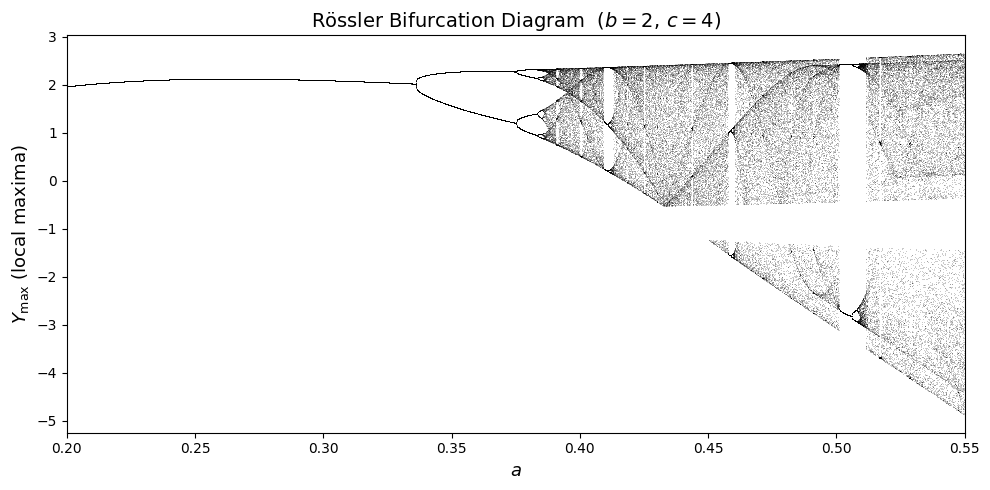

In [214]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(A_plot, Y_plot, marker='.', s=0.3, c='k', linewidths=0)

ax.set_xlabel(r'$a$', fontsize=13)
ax.set_ylabel(r'$Y_{\max}$ (local maxima)', fontsize=13)
ax.set_title(r'Rössler Bifurcation Diagram  $(b=2,\, c=4)$', fontsize=14)
ax.set_xlim(A[0], A[-1])

plt.tight_layout()
plt.show()

In [317]:
t = np.linspace(0,500,20000)
X0 = [0,0,0]
start = 2500

In [339]:
limCyc_a = 0.3
limCyc  = odeint(Rossler,X0,t,args=(limCyc_a,2,4))
limCyc = limCyc[start:].T
lc_xlim = [np.min(limCyc[0]),np.max(limCyc[0])]
lc_ylim = [np.min(limCyc[1]),np.max(limCyc[1])]
lc_zlim = [np.min(limCyc[2]),np.max(limCyc[2])]

In [341]:
pdub_a = 0.35
pdub  = odeint(Rossler,X0,t,args=(pdub_a,2,4))
pdub = pdub[start:].T
pdub_xlim = [np.min(pdub[0]),np.max(pdub[0])]
pdub_ylim = [np.min(pdub[1]),np.max(pdub[1])]
pdub_zlim = [np.min(pdub[2]),np.max(pdub[2])]

In [342]:
pdub2_a = 0.38
pdub2  = odeint(Rossler,X0,t,args=(pdub2_a,2,4))
pdub2 = pdub2[start:].T
pdub2_xlim = [np.min(pdub2[0]),np.max(pdub2[0])]
pdub2_ylim = [np.min(pdub2[1]),np.max(pdub2[1])]
pdub2_zlim = [np.min(pdub2[2]),np.max(pdub2[2])]

In [343]:
spiChaos_a = 0.45
spiChaos  = odeint(Rossler,X0,t,args=(spiChaos_a,2,4))
spiChaos = spiChaos[start:].T
spiChaos_xlim = [np.min(spiChaos[0]),np.max(spiChaos[0])]
spiChaos_ylim = [np.min(spiChaos[1]),np.max(spiChaos[1])]
spiChaos_zlim = [np.min(spiChaos[2]),np.max(spiChaos[2])]

In [331]:
clr = ['cornflowerblue',
       'tomato',
       'seagreen',
       'darkgoldenrod']

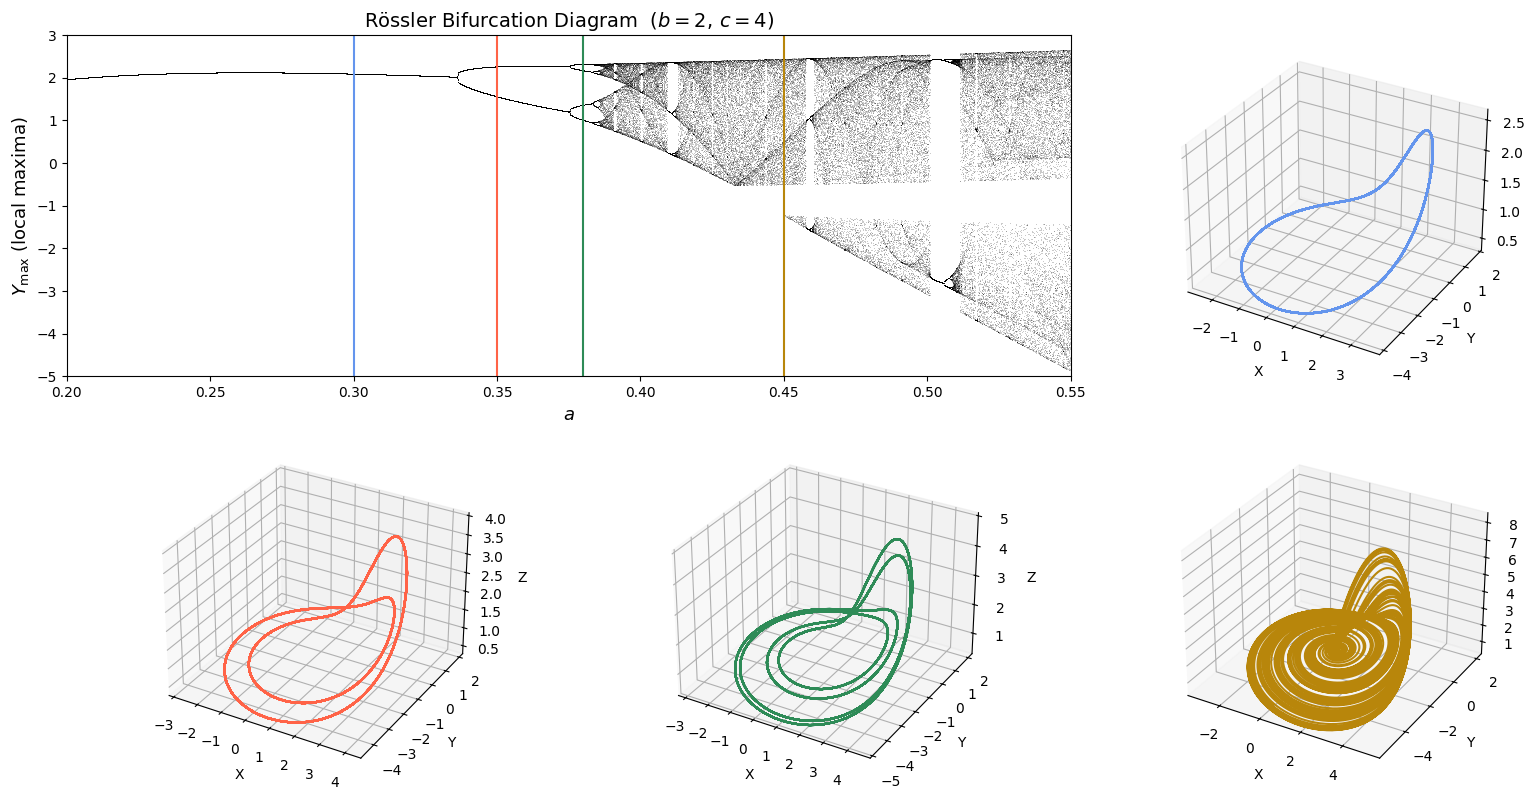

In [344]:
fig = plt.figure(figsize=(16,8))
gs = gridspec.GridSpec(2,3)

p1 = fig.add_subplot(gs[0,2],projection='3d')
p2 = fig.add_subplot(gs[1,0],projection='3d')
p3 = fig.add_subplot(gs[1,1],projection='3d')
p4 = fig.add_subplot(gs[1,2],projection='3d')
p5 = fig.add_subplot(gs[0,:2])

p1.plot(limCyc[0],limCyc[1],limCyc[2],color=clr[0])
p1.set(xlim=lc_xlim, ylim=lc_ylim, zlim=lc_zlim,
       xlabel='X', ylabel='Y', zlabel='Z')



p2.plot(pdub[0],pdub[1],pdub[2],color=clr[1])
p2.set(xlim=pdub_xlim, ylim=pdub_ylim, zlim=pdub_zlim,
       xlabel='X', ylabel='Y', zlabel='Z')



p3.plot(pdub2[0],pdub2[1],pdub2[2],color=clr[2])
p3.set(xlim=pdub2_xlim, ylim=pdub2_ylim, zlim=pdub2_zlim,
       xlabel='X', ylabel='Y', zlabel='Z')




p4.plot(spiChaos[0],spiChaos[1],spiChaos[2],color=clr[3])
p4.set(xlim=spiChaos_xlim, ylim=spiChaos_ylim, zlim=spiChaos_zlim,
       xlabel='X', ylabel='Y', zlabel='Z')




p5.scatter(A_plot, Y_plot, marker='.', s=0.3, c='k', linewidths=0)
p5.vlines([limCyc_a,pdub_a,pdub2_a,spiChaos_a],ymin=-5,ymax=3,color=clr)

p5.set_xlabel(r'$a$', fontsize=13)
p5.set_ylabel(r'$Y_{\max}$ (local maxima)', fontsize=13)
p5.set_title(r'Rössler Bifurcation Diagram  $(b=2,\, c=4)$', fontsize=14)
p5.set_xlim(A[0], A[-1])
p5.set_ylim(-5, 3)

plt.tight_layout()
plt.show()